In [1]:
import pandas as pd
import os
import math
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.container import ErrorbarContainer
from matplotlib.legend_handler import HandlerErrorbar
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

with open("matplotlibrc.json") as f:
    mpl.rcParams.update(json.load(f))

# Decoder table

In [2]:
path = os.path.join("..", "results", "brute_force")
decoder_results = [os.path.join(path, f, "results.csv") for f in os.listdir(path) if os.path.isdir(os.path.join(path, f)) and f.startswith("dec_")]
df = pd.concat([pd.read_csv(f, dtype={"clifford_deformation": str}) for f in decoder_results], ignore_index=True)
df

,seed,clifford_deformation,alpha,beta,x-err,y-err,z-err,no-err,shots,method,...,p,eta,source_file,max_bp_iters,bp_method,osd_order,osd_method,tesseract_det_beam,tesseract_pqlimit,tesseract_low_confidence_shots
0,656877229,000000000,303490,99696512,116224,3254,184011,99696511,100000000,beliefmatching,...,0.001,500.0,results/brute_force/dec_SC3_HBD_BM/results/swe...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,534085254,030303030,255591,99744411,141610,2609,111371,99744410,100000000,beliefmatching,...,0.001,500.0,results/brute_force/dec_SC3_HBD_BM/results/swe...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1063531463,033000330,285472,99714530,136162,2897,146412,99714529,100000000,beliefmatching,...,0.001,500.0,results/brute_force/dec_SC3_HBD_BM/results/swe...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,356201393,222222222,429386,99570616,215493,6574,207318,99570615,100000000,beliefmatching,...,0.001,500.0,results/brute_force/dec_SC3_HBD_BM/results/swe...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,810819441,000000000,295169,99704833,112143,2965,180060,99704832,100000000,bposd,...,0.001,500.0,results/brute_force/dec_SC3_HBD_BPOSD/results/...,30.0,product_sum,60.0,osd_cs,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,773875034,0333300300030300030033330,51259,99948743,24632,144,26482,99948742,100000000,pymatching,...,0.001,500.0,results/brute_force/dec_SC5_MHBD_MWPM/results/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,1653525683,0303030303030303030303030,42262,99957740,20134,113,22014,99957739,100000000,tesseract,...,0.001,500.0,results/brute_force/dec_SC5_MHBD_TESS/results/...,NaN,NaN,NaN,NaN,5.0,200000.0,0.0
69,1009134007,2222222222222222222222222,49135,99950867,24266,293,24575,99950866,100000000,tesseract,...,0.001,500.0,results/brute_force/dec_SC5_MHBD_TESS/results/...,NaN,NaN,NaN,NaN,5.0,200000.0,0.0
70,1044377043,0333300300030300030033330,37475,99962527,18415,102,18957,99962526,100000000,tesseract,...,0.001,500.0,results/brute_force/dec_SC5_MHBD_TESS/results/...,NaN,NaN,NaN,NaN,5.0,200000.0,0.0


## Logical error rate table

`p = 0.001`, `eta = 500`, 1e8 shots per cell. Each cell is the logical error rate
`alpha / (alpha + beta)` with its 1-sigma uncertainty on the last digits. Rows with no
data at all are dropped (CudaQ-TN is distance-3 only), and the lowest value in each row
is bolded in the LaTeX export. Swap in `fmt_ler` to drop the uncertainties.

`rank_df` holds each deformation's rank within its row (1 = lowest logical error rate).
It is not printed in the table -- four ranks per row crowds the cells more than it helps
-- but `to_latex_table(..., rank_style="sup")` will add them if that changes.

In [3]:
DECODERS = {
    "PyMatching": "pymatching",
    "BeliefMatching": "beliefmatching",
    "BP-OSD": "bposd",
    "Tesseract": "tesseract",
    "CudaQ-TN": "cudaqtensor",
}
NOISE = {"HBD": "HBD_noise", "HBD-SI1000": "MHBD_noise"}
DISTANCES = [3, 5]
CD_NAMES = {
    "CSS":    {3: "000000000", 5: "0000000000000000000000000"},
    "XZZX":   {3: "030303030", 5: "0303030303030303030303030"},
    "XY":     {3: "222222222", 5: "2222222222222222222222222"},
    "B-XZZX": {3: "033000330", 5: "0333300300030300030033330"},
}
MISSING = "--"


def fmt_ler(ler: float, unc: float | None = None, sig: int = 3) -> str:
    """Logical error rate to `sig` significant figures, e.g. 3.37e-3."""
    if not np.isfinite(ler) or ler <= 0:
        return MISSING
    exp = int(math.floor(math.log10(ler)))
    if round(ler / 10.0**exp, sig - 1) >= 10:  # rounding pushed 9.996 -> 10.0
        exp += 1
    return f"{ler / 10.0**exp:.{sig - 1}f}e{exp}"


def fmt_ler_unc(ler: float, unc: float, unc_digits: int = 2) -> str:
    """value(uncertainty), e.g. 3.0349(55)e-3 -- the parenthesised digits are the
    1-sigma uncertainty on the last shown digits of the mantissa."""
    if not np.isfinite(ler) or ler <= 0:
        return MISSING
    exp = int(math.floor(math.log10(ler)))
    mant, mant_unc = ler / 10.0**exp, unc / 10.0**exp
    dec = max(0, -int(math.floor(math.log10(mant_unc))) + unc_digits - 1)
    paren = round(mant_unc * 10**dec)
    if paren >= 10**unc_digits:  # rounding pushed 99 -> 100
        dec -= 1
        paren = round(mant_unc * 10**dec)
    return f"{mant:.{dec}f}({paren})e{exp}"


def decoder_frames(df: pd.DataFrame, drop_empty: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Logical error rates and their 1-sigma uncertainties, one row per
    (distance, noise model, decoder) and one column per named Clifford deformation.

    Every (method, noise, d, cd) combination has exactly one row in the brute-force
    results, so no pooling of Beta posteriors is needed here. With `drop_empty`, rows
    for which no decoder run exists are dropped rather than kept as NaN (CudaQ-TN is
    distance-3 only). These two frames are the single numeric source that the LaTeX
    table, the ranks and the figure are all derived from.
    """
    d = df.copy()
    n = d["alpha"] + d["beta"]
    d["ler"] = d["alpha"] / n
    d["ler_unc"] = np.sqrt(d["alpha"] * d["beta"] / n**2 / (n + 1))
    lookup = d.set_index(["method", "noise-model", "d", "clifford_deformation"])[["ler", "ler_unc"]]

    index, lers, uncs = [], [], []
    for distance in DISTANCES:
        for noise_label, noise in NOISE.items():
            for decoder, method in DECODERS.items():
                row_ler, row_unc = [], []
                for cds in CD_NAMES.values():
                    key = (method, noise, distance, cds[distance])
                    if key in lookup.index:
                        r = lookup.loc[key]
                        row_ler.append(float(r["ler"]))
                        row_unc.append(float(r["ler_unc"]))
                    else:
                        row_ler.append(np.nan)
                        row_unc.append(np.nan)
                if drop_empty and all(np.isnan(v) for v in row_ler):
                    continue
                index.append((distance, noise_label, decoder))
                lers.append(row_ler)
                uncs.append(row_unc)

    idx = pd.MultiIndex.from_tuples(index, names=["Distance", "noise model", "Decoder"])
    cols = list(CD_NAMES)
    return pd.DataFrame(lers, index=idx, columns=cols), pd.DataFrame(uncs, index=idx, columns=cols)


def decoder_table(ler_df: pd.DataFrame, unc_df: pd.DataFrame, formatter=fmt_ler_unc) -> pd.DataFrame:
    """Format the numeric frames for display, MISSING wherever no run exists."""
    return pd.DataFrame(
        [[formatter(ler, unc) if np.isfinite(ler) else MISSING for ler, unc in zip(lrow, urow)] for lrow, urow in zip(ler_df.to_numpy(), unc_df.to_numpy())],
        index=ler_df.index,
        columns=ler_df.columns,
    )


ler_df, unc_df = decoder_frames(df)
# Rank of each Clifford deformation within its row, 1 = lowest logical error rate.
rank_df = ler_df.rank(axis=1, method="min").astype("Int64")
table_df = decoder_table(ler_df, unc_df)
table_df

CSS           XZZX  \
Distance noise model Decoder                                        
3        HBD         PyMatching      3.3731(58)e-3  2.6005(51)e-3   
                     BeliefMatching  3.0349(55)e-3  2.5559(50)e-3   
                     BP-OSD          2.9517(54)e-3  2.4657(50)e-3   
                     Tesseract       2.7454(52)e-3  1.9830(44)e-3   
                     CudaQ-TN        2.6836(52)e-3  1.9344(44)e-3   
         HBD-SI1000  PyMatching      4.3723(66)e-3  3.9204(62)e-3   
                     BeliefMatching  4.1204(64)e-3  3.6532(60)e-3   
                     BP-OSD          4.0457(63)e-3  3.6107(60)e-3   
                     Tesseract       3.7870(61)e-3  3.3101(57)e-3   
                     CudaQ-TN        3.7244(61)e-3  3.3202(58)e-3   
5        HBD         PyMatching       6.508(26)e-4   3.535(19)e-4   
                     BeliefMatching   4.933(22)e-4   2.705(16)e-4   
                     BP-OSD           4.245(21)e-4   2.219(15)e-4   
                     Tesseract        3.872(20)e-4   1.999(14)e-4   
         HBD-SI1000  PyMatching       7.377(27)e-4   5.422(23)e-4   
                     BeliefMatching   6.945(26)e-4   5.139(23)e-4   
                     BP-OSD           6.108(25)e-4   4.397(21)e-4   
                     Tesseract        5.963(24)e-4   4.226(21)e-4   

                                                XY         B-XZZX  
Distance noise model Decoder                                       
3        HBD         PyMatching      5.3951(73)e-3  3.2569(57)e-3  
                     BeliefMatching  4.2939(65)e-3  2.8547(53)e-3  
                     BP-OSD          4.0424(63)e-3  2.7748(53)e-3  
                     Tesseract       3.8773(62)e-3  2.5950(51)e-3  
                     CudaQ-TN        3.8531(62)e-3  2.5228(50)e-3  
         HBD-SI1000  PyMatching      6.4594(80)e-3  3.7263(61)e-3  
                     BeliefMatching  4.4681(67)e-3  3.6063(60)e-3  
                     BP-OSD          4.1056(64)e-3  3.5602(60)e-3  
                     Tesseract       3.9329(63)e-3  3.0559(55)e-3  
                     CudaQ-TN        3.9858(63)e-3  3.0794(55)e-3  
5        HBD         PyMatching      1.3368(37)e-3   4.646(22)e-4  
                     BeliefMatching   7.323(27)e-4   3.552(19)e-4  
                     BP-OSD           5.859(24)e-4   2.945(17)e-4  
                     Tesseract        5.234(23)e-4   2.700(16)e-4  
         HBD-SI1000  PyMatching      1.2364(35)e-3   5.126(23)e-4  
                     BeliefMatching   6.628(26)e-4   4.682(22)e-4  
                     BP-OSD           5.244(23)e-4   3.949(20)e-4  
                     Tesseract        4.913(22)e-4   3.747(19)e-4

### Are the ranks meaningful?

A rank is only worth printing if the deformations it orders are actually separated by
more than their error bars. This checks the tightest adjacent pair in every row.

In [4]:
# Are the ranks actually resolved by the data? Smallest gap between adjacently
# ranked deformations, in sigma, for every (distance, noise model, decoder).
gaps = []
for key, row in ler_df.iterrows():
    unc, order = unc_df.loc[key], row.sort_values().index
    z = [(row[b] - row[a]) / np.sqrt(unc[a] ** 2 + unc[b] ** 2) for a, b in zip(order[:-1], order[1:])]
    gaps.append((*key, " < ".join(order), min(z)))

gap_df = pd.DataFrame(gaps, columns=["Distance", "noise model", "Decoder", "order", "min gap [sigma]"])
print(f"smallest adjacent-rank gap anywhere in the table: {gap_df['min gap [sigma]'].min():.1f} sigma")
gap_df

smallest adjacent-rank gap anywhere in the table: 5.5 sigma


,Distance,noise model,Decoder,order,min gap [sigma]
0,3,HBD,PyMatching,XZZX < B-XZZX < CSS < XY,14.293335
1,3,HBD,BeliefMatching,XZZX < B-XZZX < CSS < XY,23.512778
2,3,HBD,BP-OSD,XZZX < B-XZZX < CSS < XY,23.407624
3,3,HBD,Tesseract,XZZX < B-XZZX < CSS < XY,20.616437
4,3,HBD,CudaQ-TN,XZZX < B-XZZX < CSS < XY,22.317019
5,3,HBD-SI1000,PyMatching,B-XZZX < XZZX < CSS < XY,22.240361
6,3,HBD-SI1000,BeliefMatching,B-XZZX < XZZX < CSS < XY,5.505124
7,3,HBD-SI1000,BP-OSD,B-XZZX < XZZX < CSS < XY,5.983730
8,3,HBD-SI1000,Tesseract,B-XZZX < XZZX < CSS < XY,16.639838
9,3,HBD-SI1000,CudaQ-TN,B-XZZX < XZZX < CSS < XY,29.826154


### LaTeX export

Needs `\usepackage{multirow}`. Noise models within a distance are split by
`\cline{2-7}` rather than a full `\hline`, so the `\multirow` distance label stays
uncut.

In [5]:
import re

_SCI = re.compile(r"^([\d.]+)(\(\d+\))?e([+-]?\d+)$")
EOL = "\\" + "\\"  # LaTeX row terminator


def _split(cell: str):
    """3.37e-3 -> ("3.37", "", -3); returns None for a MISSING cell."""
    m = _SCI.match(cell)
    return None if m is None else (m.group(1), m.group(2) or "", int(m.group(3)))


def _rank_mark(rank, style: str) -> str:
    r"""Rank badge, placed outside the $...$ so a text-mode superscript keeps it clear
    of the 10^{-n} exponent it would otherwise sit beside."""
    if style == "none" or rank is None or pd.isna(rank):
        return ""
    if style == "sup":
        return rf"\textsuperscript{{({int(rank)})}}"
    if style == "tag":
        return rf"\,{{\scriptsize[{int(rank)}]}}"
    raise ValueError(f"unknown rank_style {style!r}")


def _to_math(cell: str, bold: bool = False, rank=None, rank_style: str = "sup") -> str:
    r"""3.37e-3 -> $3.37 \times 10^{-3}$\textsuperscript{(2)}"""
    parts = _split(cell)
    if parts is None:
        return r"---"
    mant, unc, exp = parts
    body = rf"{mant}{unc} \times 10^{{{exp}}}"
    return (rf"$\mathbf{{{body}}}$" if bold else f"${body}$") + _rank_mark(rank, rank_style)


def _multirow(label: str, span: int) -> str:
    r"""\multirow only when the group actually spans more than one row."""
    return rf"\multirow{{{span}}}{{*}}{{{label}}}" if span > 1 else label


def to_latex_table(table_df: pd.DataFrame, rank_df: pd.DataFrame, bold_min: bool = True,
                   rank_style: str = "none", indent: str = " " * 4) -> str:
    r"""Render the decoder table as a LaTeX tabular with \multirow distance/noise groups.

    With `bold_min` the lowest logical error rate in each row (rank 1) is set in \mathbf.
    `rank_style` can print each cell's rank within its row alongside the value -- "sup"
    (raised, parenthesised) or "tag" (bracketed, on the baseline) -- but defaults to
    "none": four ranks per row crowds the cells more than it helps, and the ordering is
    the figure's job.

    Noise models within a distance are separated by \cline over every column but the
    Distance one, so the \multirow distance label is not cut; distances by a \hline.
    Needs \usepackage{multirow} in the preamble.
    """
    n_cols = len(table_df.index.names) + len(table_df.columns)
    lines = [rf"\begin{{tabular}}{{ccc|{'c' * len(table_df.columns)}}}"]
    lines.append(indent + " & ".join(list(table_df.index.names) + list(table_df.columns)) + " " + EOL)
    lines.append(indent + r"\hline")

    for i, distance in enumerate(dict.fromkeys(table_df.index.get_level_values("Distance"))):
        block = table_df.xs(distance, level="Distance")
        if i:
            lines.append(indent + r"\hline")
        first_of_distance = True
        for j, noise in enumerate(dict.fromkeys(block.index.get_level_values("noise model"))):
            sub = block.xs(noise, level="noise model")
            if j:
                lines.append(indent + rf"\cline{{2-{n_cols}}}")
            first_of_noise = True
            for decoder, row in sub.iterrows():
                ranks = rank_df.loc[(distance, noise, decoder)]
                cells = [_to_math(c, bold=bold_min and ranks[cd] == 1,
                                  rank=ranks[cd], rank_style=rank_style)
                         for cd, c in row.items()]
                col1 = _multirow(str(distance), len(block)) if first_of_distance else ""
                col2 = _multirow(noise, len(sub)) if first_of_noise else ""
                lines.append(f"{indent}{col1} & {col2} & {decoder} & " + " & ".join(cells) + " " + EOL)
                first_of_distance = first_of_noise = False

    lines.append(r"\end{tabular}")
    return "\n".join(lines)

table = to_latex_table(table_df, rank_df)
display(table_df)
with open("outputs/tables/decoder_table.tex", "w") as f:
    f.write(table)

CSS           XZZX  \
Distance noise model Decoder                                        
3        HBD         PyMatching      3.3731(58)e-3  2.6005(51)e-3   
                     BeliefMatching  3.0349(55)e-3  2.5559(50)e-3   
                     BP-OSD          2.9517(54)e-3  2.4657(50)e-3   
                     Tesseract       2.7454(52)e-3  1.9830(44)e-3   
                     CudaQ-TN        2.6836(52)e-3  1.9344(44)e-3   
         HBD-SI1000  PyMatching      4.3723(66)e-3  3.9204(62)e-3   
                     BeliefMatching  4.1204(64)e-3  3.6532(60)e-3   
                     BP-OSD          4.0457(63)e-3  3.6107(60)e-3   
                     Tesseract       3.7870(61)e-3  3.3101(57)e-3   
                     CudaQ-TN        3.7244(61)e-3  3.3202(58)e-3   
5        HBD         PyMatching       6.508(26)e-4   3.535(19)e-4   
                     BeliefMatching   4.933(22)e-4   2.705(16)e-4   
                     BP-OSD           4.245(21)e-4   2.219(15)e-4   
                     Tesseract        3.872(20)e-4   1.999(14)e-4   
         HBD-SI1000  PyMatching       7.377(27)e-4   5.422(23)e-4   
                     BeliefMatching   6.945(26)e-4   5.139(23)e-4   
                     BP-OSD           6.108(25)e-4   4.397(21)e-4   
                     Tesseract        5.963(24)e-4   4.226(21)e-4   

                                                XY         B-XZZX  
Distance noise model Decoder                                       
3        HBD         PyMatching      5.3951(73)e-3  3.2569(57)e-3  
                     BeliefMatching  4.2939(65)e-3  2.8547(53)e-3  
                     BP-OSD          4.0424(63)e-3  2.7748(53)e-3  
                     Tesseract       3.8773(62)e-3  2.5950(51)e-3  
                     CudaQ-TN        3.8531(62)e-3  2.5228(50)e-3  
         HBD-SI1000  PyMatching      6.4594(80)e-3  3.7263(61)e-3  
                     BeliefMatching  4.4681(67)e-3  3.6063(60)e-3  
                     BP-OSD          4.1056(64)e-3  3.5602(60)e-3  
                     Tesseract       3.9329(63)e-3  3.0559(55)e-3  
                     CudaQ-TN        3.9858(63)e-3  3.0794(55)e-3  
5        HBD         PyMatching      1.3368(37)e-3   4.646(22)e-4  
                     BeliefMatching   7.323(27)e-4   3.552(19)e-4  
                     BP-OSD           5.859(24)e-4   2.945(17)e-4  
                     Tesseract        5.234(23)e-4   2.700(16)e-4  
         HBD-SI1000  PyMatching      1.2364(35)e-3   5.126(23)e-4  
                     BeliefMatching   6.628(26)e-4   4.682(22)e-4  
                     BP-OSD           5.244(23)e-4   3.949(20)e-4  
                     Tesseract        4.913(22)e-4   3.747(19)e-4

## Decoder runtime table

How much the extra decoding power in the table above costs. The `results.csv` files carry
no timing, so this reads the Slurm logs stored inside each job's `raw.zip`: every
`*_candidate.py` prints a progress line before each Clifford deformation and one after the
last, so the wall clock of a deformation is the gap between consecutive lines.

The table is laid out with the five decoders as rows and the four experiments (distance x
noise model) as columns -- the transpose of the logical error rate table, since a runtime
row is a property of the decoder. Each cell is the runtime relative to PyMatching on the
same experiment with the wall clock in parentheses, and the last column names the hardware
the row ran on.

Three caveats on what these numbers are:

- **Sampling is included.** The clock starts after the code and the noise model are built,
  but each deformation's interval covers `candidate.sample(...)`, i.e. Stim sampling *and*
  decoding of 1e8 shots. Sampling is a real fraction of the PyMatching intervals and a
  rounding error in the others, so the ratios below *understate* the decode-only gap.
- **CudaQ-TN is not hardware-comparable.** Every CPU decoder was given a single core of a
  `qist-fat` node (2 sockets x 48 cores at 3.65 GHz, 1.5 TB), while CudaQ-TN ran on
  `qist-gpu` and used one of that node's four H200 NVL GPUs (141 GB, CUDA 13.3). Its
  ratios are wall clock against one CPU core, not a like-for-like comparison.
- **`max_shot_size` differs per decoder** (1e6 for PyMatching, 1e5 for BeliefMatching, 1e4
  for BP-OSD, Tesseract and CudaQ-TN), which changes the per-batch overhead.

`spread` in `runtime_df` is max/min over the four deformations of a row -- a sanity check
on how repeatable a row is, since the four array tasks are otherwise near-identical work.
It is not printed in the table.

In [6]:
import zipfile

# "    1/4: time used:  0h 53m  6s, remaining time:  2h 39m 18s"
TIME_RE = re.compile(r"^\s*(\d+)/(\d+): time used:\s*(\d+)h\s*(\d+)m\s*(\d+)s")
# "clifford_deformations: ['000000000']" from the argument echo at the top of the log
CDS_RE = re.compile(r"^clifford_deformations: \[(.*)\]")
JOB_RE = re.compile(r"^dec_SC(\d+)_(M?HBD)_([A-Z]+)$")
JOB_DECODER = {"MWPM": "PyMatching", "BM": "BeliefMatching", "BP-OSD": "BP-OSD",
               "BPOSD": "BP-OSD", "TESS": "Tesseract", "TN": "CudaQ-TN"}
BASELINE = "PyMatching"
CD_LOOKUP = {cds[d]: name for name, cds in CD_NAMES.items() for d in DISTANCES}


def parse_log(text: str) -> list[tuple[str, int]]:
    """(clifford deformation, seconds) for every deformation finished in one array task.

    The progress line `i/N` is printed *before* deformation `i` is sampled and the line
    `N/N` after the last one, so consecutive checkpoints bracket exactly one deformation
    and `np.diff` turns them into durations. Deformations are consumed in the order of
    the `clifford_deformations` argument, and `zip` stops at the shorter of the two
    sequences -- so a task that hit its time limit contributes the deformations it
    finished and drops the one it was cut off in.
    """
    cds, checkpoints = [], []
    for line in text.splitlines():
        m = CDS_RE.match(line)
        if m:
            cds = [s.strip().strip("'\"") for s in m.group(1).split(",") if s.strip()]
        m = TIME_RE.match(line)
        if m:
            h, minutes, s = (int(g) for g in m.groups()[2:])
            checkpoints.append(3600 * h + 60 * minutes + s)
    return list(zip(cds, (int(dt) for dt in np.diff(checkpoints))))


def runtime_records(path: str = path) -> pd.DataFrame:
    """One row per (job, Clifford deformation) from the logs inside every `dec_*/raw.zip`."""
    rows = []
    for folder in sorted(os.listdir(path)):
        job = JOB_RE.match(folder)
        zip_path = os.path.join(path, folder, "raw.zip")
        if job is None or not os.path.isfile(zip_path):
            continue
        distance, noise = int(job.group(1)), job.group(2)
        decoder = JOB_DECODER[job.group(3)]
        with zipfile.ZipFile(zip_path) as archive:
            logs = sorted(n for n in archive.namelist()
                          if n.startswith("logs/") and n.endswith(".out"))
            for name in logs:
                text = archive.read(name).decode("utf-8", "replace")
                for cd, seconds in parse_log(text):
                    rows.append((distance, noise, decoder, CD_LOOKUP.get(cd, cd), name, seconds))
    return pd.DataFrame(rows, columns=["Distance", "noise model", "Decoder",
                                       "Clifford deformation", "log", "seconds"])


def runtime_frames(records: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Per-deformation seconds, and the row summary the LaTeX table is rendered from.

    Rows are ordered exactly as in the logical error rate table, so the two can be read
    side by side. `relative` divides each row's mean by the PyMatching mean of the same
    (distance, noise model), which is the "how many times slower than MWPM" column.
    """
    per_cd = records.pivot_table(index=["Distance", "noise model", "Decoder"],
                                 columns="Clifford deformation", values="seconds")
    order = [(d, n, dec) for d in DISTANCES for n in NOISE for dec in DECODERS
             if (d, n, dec) in per_cd.index]
    per_cd = per_cd.reindex(
        index=pd.MultiIndex.from_tuples(order, names=["Distance", "noise model", "Decoder"]),
        columns=list(CD_NAMES),
    )

    mean = per_cd.mean(axis=1)
    baseline = mean.xs(BASELINE, level="Decoder")  # one PyMatching row per experiment
    keys = pd.MultiIndex.from_tuples([(d, n) for d, n, _ in mean.index])
    summary = pd.DataFrame({
        "seconds": mean,
        "spread": per_cd.max(axis=1) / per_cd.min(axis=1),
        "relative": mean.to_numpy() / baseline.reindex(keys).to_numpy(),
    })
    return per_cd, summary


runtime_records_df = runtime_records()
per_cd_seconds, runtime_df = runtime_frames(runtime_records_df)
runtime_df

seconds    spread    relative
Distance noise model Decoder                                        
3        HBD         PyMatching          25.50  1.080000    1.000000
                     BeliefMatching    3185.75  1.165934  124.931373
                     BP-OSD            4290.75  1.222279  168.264706
                     Tesseract         6577.75  1.171742  257.950980
                     CudaQ-TN          2471.75  1.034765   96.931373
5        HBD         PyMatching         394.00  1.881919    1.000000
                     BeliefMatching   80453.25  1.256410  204.196066
                     BP-OSD          162559.75  1.335319  412.588198
                     Tesseract        97384.25  1.212872  247.168147

### LaTeX export

Needs `\usepackage{multirow}`. The distance labels span their two noise models with
`\multicolumn`, and the compute resource header spans both header rows. Pass
`latex_units=False` for plain `413 (45 h 09 m)` cells instead of
`413 ($45\,\mathrm{h}\,09\,\mathrm{m}$)`, or `resources=False` to drop the hardware column.

In [7]:
def fmt_duration(seconds: float, latex: bool = True) -> str:
    r"""Wall clock in the two largest units that carry information: 25.5 s, 53 m 06 s,
    45 h 09 m. Sub-minute values keep 3 significant figures, everything else is rounded
    to the second and then truncated to two units -- an hours-long run is not repeatable
    to the second anyway (see the `spread` column of `runtime_df`)."""
    if not np.isfinite(seconds):
        return MISSING
    total = int(round(seconds))
    if seconds < 60:
        parts = [(f"{seconds:.3g}", "s")]
    elif seconds < 3600:
        parts = [(f"{total // 60}", "m"), (f"{total % 60:02d}", "s")]
    else:
        parts = [(f"{total // 3600}", "h"), (f"{total % 3600 // 60:02d}", "m")]
    if not latex:
        return " ".join(f"{value} {unit}" for value, unit in parts)
    return "$" + r"\,".join(rf"{value}\,\mathrm{{{unit}}}" for value, unit in parts) + "$"


def fmt_ratio(ratio: float, sig: int = 3) -> str:
    """Dimensionless ratio to `sig` significant figures: 1, 96.9, 413."""
    return MISSING if not np.isfinite(ratio) else f"{ratio:.{sig}g}"


# What every row of the table actually ran on. The CPU jobs each took a single core of a
# 2 x 48-core, 3.65 GHz, 1.5 TB node; CudaQ-TN took one GPU of a 4 x H200 NVL node.
COMPUTE = {
    "PyMatching":     "1 core, AMD EPYC 9475F",
    "BeliefMatching": "1 core, AMD EPYC 9475F",
    "BP-OSD":         "1 core, AMD EPYC 9475F",
    "Tesseract":      "1 core, AMD EPYC 9475F",
    "CudaQ-TN":       "1 NVIDIA H200 NVL, 141 GB",
}
RESOURCE_COLUMN = "Compute resource"


def runtime_table_wide(summary: pd.DataFrame, latex_units: bool = True,
                       resources: bool = True) -> pd.DataFrame:
    r"""Decoders as rows, the (distance, noise model) experiments as columns.

    Each cell is the runtime relative to PyMatching on the same experiment with the wall
    clock in parentheses -- `413 (45 h 09 m)` -- so a row reads as "how much this decoder
    costs" and a column as "what the experiment costs". The trailing column names the
    hardware, which is what makes the CudaQ-TN row's ratios incomparable to the rest.
    """
    columns = {}
    for distance in DISTANCES:
        for noise in NOISE:
            cells = []
            for decoder in DECODERS:
                key = (distance, noise, decoder)
                if key not in summary.index or not np.isfinite(summary.at[key, "seconds"]):
                    cells.append(r"---" if latex_units else MISSING)
                    continue
                ratio = fmt_ratio(summary.at[key, "relative"])
                clock = fmt_duration(summary.at[key, "seconds"], latex_units)
                # cells.append(f"{ratio} ({clock})")
                cells.append(f"{clock} (${ratio}\\times$)")
            columns[(rf"$d = {distance}$" if latex_units else f"d = {distance}", noise)] = cells

    table = pd.DataFrame(columns, index=pd.Index(list(DECODERS), name="Decoder"))
    table.columns = pd.MultiIndex.from_tuples(table.columns)
    if resources:
        table[(RESOURCE_COLUMN, "")] = [COMPUTE[decoder] for decoder in DECODERS]
    return table


def to_latex_wide(table: pd.DataFrame, indent: str = " " * 4) -> str:
    r"""LaTeX tabular for the wide runtime table.

    Cells are taken verbatim, so the caller owns their formatting. The distance labels
    span their noise models with `\multicolumn`, and any column whose second header level
    is empty (the compute resource) spans both header rows with `\multirow`. Needs
    `\usepackage{multirow}`.
    """
    experiments = [column for column in table.columns if column[1]]
    extras = [column for column in table.columns if not column[1]]
    groups = {}
    for label, noise in experiments:
        groups.setdefault(label, []).append(noise)

    blocks = ["c" * len(noises) for noises in groups.values()]
    spec = "l|" + "|".join(blocks) + ("|l" if extras else "")

    spans = []
    for i, (label, noises) in enumerate(groups.items()):
        edge = "c|" if extras or i < len(groups) - 1 else "c"
        spans.append(rf"\multicolumn{{{len(noises)}}}{{{edge}}}{{{label}}}")
    head = [rf"\multirow{{2}}{{*}}{{{table.index.name}}}", *spans,
            *(rf"\multirow{{2}}{{*}}{{{label}}}" for label, _ in extras)]
    sub = ["", *(noise for _, noise in experiments), *("" for _ in extras)]

    lines = [rf"\begin{{tabular}}{{{spec}}}",
             indent + " & ".join(head) + " " + EOL,
             indent + " & ".join(sub) + " " + EOL,
             indent + r"\hline"]
    for decoder, row in table.iterrows():
        lines.append(f"{indent}{decoder} & " + " & ".join(row) + " " + EOL)
    lines += [r"\end{tabular}"]
    return "\n".join(lines)


runtime_table_df = runtime_table_wide(runtime_df)
display(runtime_table_wide(runtime_df, latex_units=False))
table = to_latex_wide(runtime_table_df)
with open("outputs/tables/runtime_table.tex", "w") as f:
    f.write(table)

d = 3                               d = 5  \
                                     HBD HBD-SI1000                      HBD   
Decoder                                                                        
PyMatching            25.5 s ($1\times$)         --     6 m 34 s ($1\times$)   
BeliefMatching   53 m 06 s ($125\times$)         --  22 h 20 m ($204\times$)   
BP-OSD            1 h 11 m ($168\times$)         --  45 h 09 m ($413\times$)   
Tesseract         1 h 49 m ($258\times$)         --  27 h 03 m ($247\times$)   
CudaQ-TN        41 m 12 s ($96.9\times$)         --                       --   

                                    Compute resource  
               HBD-SI1000                             
Decoder                                               
PyMatching             --     1 core, AMD EPYC 9475F  
BeliefMatching         --     1 core, AMD EPYC 9475F  
BP-OSD                 --     1 core, AMD EPYC 9475F  
Tesseract              --     1 core, AMD EPYC 9475F  
CudaQ-TN               --  1 NVIDIA H200 NVL, 141 GB

## Ranking figure

The table answers "which deformation wins" per row; this answers "does that answer
depend on the decoder". One panel per experiment (distance x noise model), decoders
left to right in increasing decoding power, so the vertical order of the lines is the
ranking and a crossing is a change of ranking.

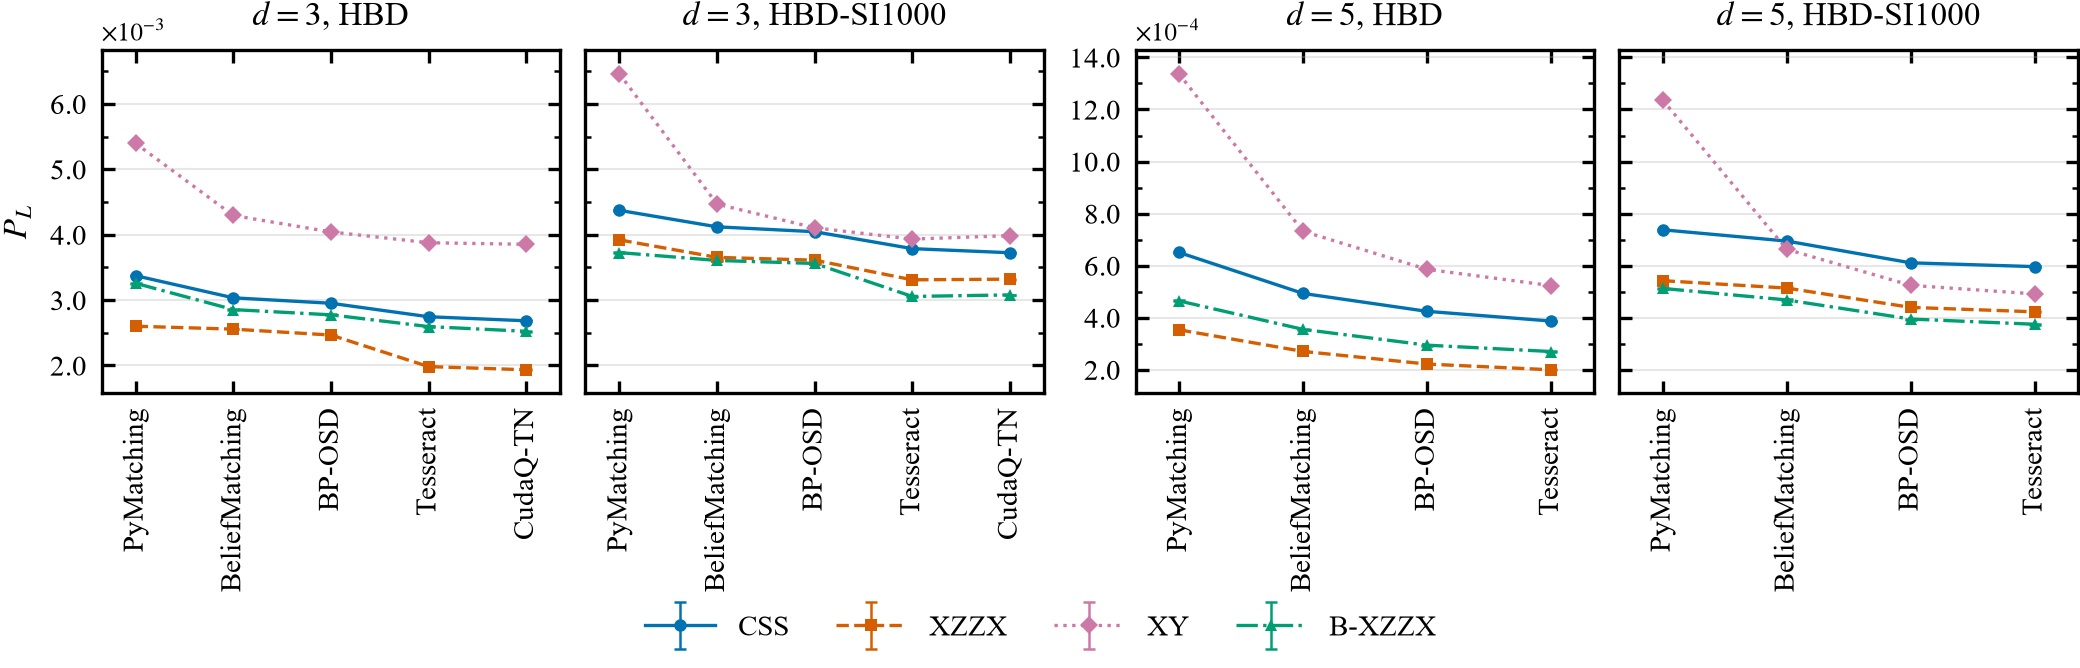

In [8]:
# Okabe-Ito hues. On white this palette clears the lightness, chroma and contrast
# checks outright (min contrast 3.06:1), but the green/purple pair sits at
# dE = 7.6 under deuteranopia -- inside the 6-8 band where colour alone is not
# enough -- so marker shape and dash pattern carry the identity as well.
CD_STYLE = {
    "CSS":    ("#0072B2", "o", "-"),    # blue
    "XZZX":   ("#D55E00", "s", "--"),   # vermillion
    "XY":     ("#CC79A7", "D", ":"),    # reddish purple
    "B-XZZX": ("#009E73", "^", "-."),   # bluish green
}
DECODER_SHORT = {
    "PyMatching": "PyMatching", 
    "BeliefMatching": "BeliefMatching",
    "BP-OSD": "BP-OSD",
    "Tesseract": "Tesseract", 
    "CudaQ-TN": "CudaQ-TN"
}
# DECODER_SHORT = {
#     "PyMatching": "MWPM", 
#     "BeliefMatching": "BM",
#     "BP-OSD": "BP-OSD",
#     "Tesseract": "Tess", 
#     "CudaQ-TN": "TN"
# }


def _nice_step(span: float, target: int = 7) -> float:
    """Round `span / target` up to the next 1-2-2.5-5 style tick spacing."""
    raw = span / target
    decade = 10.0 ** np.floor(np.log10(raw))
    for mult in (1, 2, 2.5, 5, 10):
        if mult * decade >= raw:
            return mult * decade
    return 10 * decade


def plot_decoder_ranking(ler_df, unc_df, figsize=(7.0, 2.3), pad=0.35, y_pad=0.08):
    """One panel per experiment, decoders left to right in increasing decoding power.

    Logical error rate with one line per Clifford deformation, so the vertical order of
    the lines is the ranking and a crossing is a change of ranking. Panels of the same
    distance share limits and a single power of ten -- that keeps the two noise models
    directly comparable, while still letting d=5 use the full axis height instead of
    being squashed into the bottom of a d=3 scale.

    As in comparizon.ipynb, the values carry the factor and the axis stays linear, with
    the multiplier stated above the frame rather than repeated on every tick label.
    """
    panels = list(dict.fromkeys(zip(ler_df.index.get_level_values("Distance"),
                                    ler_df.index.get_level_values("noise model"))))
    fig, axes = plt.subplots(1, len(panels), figsize=figsize)

    # One power of ten per distance, from the smallest rate that distance reaches.
    powers = {d: int(np.floor(np.log10(np.nanmin(ler_df.xs(d, level="Distance").to_numpy()))))
              for d in dict.fromkeys(d for d, _ in panels)}

    handles = {}
    for ax, (distance, noise) in zip(axes, panels):
        levels = ("Distance", "noise model")
        ler = ler_df.xs((distance, noise), level=levels)
        unc = unc_df.xs((distance, noise), level=levels)
        decoders, x = list(ler.index), np.arange(len(ler.index))
        factor = 10.0 ** -powers[distance]

        for cd, (color, marker, linestyle) in CD_STYLE.items():
            bars = ax.errorbar(x, factor * ler[cd].to_numpy(), yerr=factor * unc[cd].to_numpy(),
                               color=color, marker=marker, linestyle=linestyle, linewidth=0.8, markersize=3,
                               capsize=1.5, elinewidth=0.6, markeredgewidth=0, zorder=3)
            # markeredgewidth=0 keeps the data markers clean, but errorbar documents it
            # as overriding capthick, which would leave the caps zero-width -- invisible
            # in the legend key too. Set the cap thickness on the caplines directly.
            for cap in bars[1]:
                cap.set_markeredgewidth(0.6)
            handles.setdefault(cd, bars)

        ax.set_xticks(x, [DECODER_SHORT[d] for d in decoders], rotation=90)
        ax.set_xlim(-pad, len(decoders) - 1 + pad)
        ax.set_title(rf"$d={distance}$, {noise}")
        ax.grid(axis="y", which="major")

    # Shared limits and ticks per distance, over both noise models of that distance.
    for distance, power in powers.items():
        group = [ax for ax, (d, _) in zip(axes, panels) if d == distance]
        values = ler_df.xs(distance, level="Distance").to_numpy() * 10.0**-power
        low, high = np.nanmin(values), np.nanmax(values)
        span = high - low
        step = _nice_step(span * (1 + 2 * y_pad))
        for i, ax in enumerate(group):
            ax.set_ylim(low - y_pad * span, high + y_pad * span)
            ax.yaxis.set_major_locator(MultipleLocator(step))
            ax.yaxis.set_minor_locator(MultipleLocator(step / 2))
            # one decimal on every panel: integer labels would be narrower and would
            # let the axes box grow, breaking alignment with the other panels
            ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
            if i:  # reads off its neighbour's ticks
                ax.tick_params(axis="y", labelleft=False)
            else:  # the y axis carries a factor, so state it above the frame
                ax.text(0.0, 1.01, rf"$\times10^{{{power}}}$", transform=ax.transAxes,
                        fontsize=6, va="bottom", ha="left")

    axes[0].set_ylabel("$P_L$")
    # The keys are the real ErrorbarContainers, not stand-in Line2Ds: matplotlib draws
    # their bars at a fixed size in the legend, so the key advertises the error bars
    # even though on the data they are a fraction of a point tall (1e8 shots puts
    # 1 sigma at 0.1-0.7% of the value). A plain line key would read as "no error bars".
    fig.legend(handles=list(handles.values()), labels=list(handles),
               loc="outside lower center", ncol=len(CD_STYLE),
               columnspacing=1.6, handlelength=2.4,
               handler_map={ErrorbarContainer: HandlerErrorbar(yerr_size=0.8)})
    return fig, axes


fig, axes = plot_decoder_ranking(ler_df, unc_df)
fig.savefig("outputs/tables/decoder_ranking.pdf", transparent=True)
plt.show()